# Notebook 6 — Bootstrap 90% confidence intervals for $M_1$ on corrected data

**Goal.** Fill in the `[\ldots, \ldots]` placeholders in the paper's section 4.3.

Reuse the histograms cached in `ml_data/` by notebook 5. Rebuild the corrected-$C_g$ dataset and draw $B = 1000$ bootstrap samples with replacement. For each sample, refit $M_1$ (weighted LS of the linear residual on top of Wolf) and record coefficients $a, b, c$.

Report: point estimate, 5/50/95 percentile, std, 90% CI. Also plot the three bootstrap histograms as the paper's Figure 8.

**Runtime.** ~10 s (bootstrap is trivial on 110-point dataset).


In [1]:
import math, time
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import integrate
import matplotlib.pyplot as plt

DATA_DIR = Path.cwd() / 'ml_data'
C2_TWIN = 0.6601618158468695739278121100145557784326233602847334133194484233354

def hl_correct(g):
    if g <= 0 or g % 2: return 0.0
    n = g
    while n % 2 == 0: n //= 2
    corr, p = 1.0, 3
    while p*p <= n:
        if n % p == 0:
            corr *= (p-1)/(p-2)
            while n % p == 0: n //= p
        p += 2
    if n > 1: corr *= (n-1)/(n-2)
    return 2*C2_TWIN*corr

def omega(n):
    if n <= 1: return 0
    c, d = 0, 2
    while d*d <= n:
        if n % d == 0:
            c += 1
            while n % d == 0: n //= d
        d += 1
    if n > 1: c += 1
    return c

def li2(N):
    v, _ = integrate.quad(lambda t: 1.0/np.log(t)**2, 2.0, N, limit=200)
    return float(v)

# Load cached histograms
cached = sorted(DATA_DIR.glob('gaps_N*.csv'))
assert cached, 'run notebook 5 first to populate ml_data/'
histograms = {}
for f in cached:
    N = int(f.stem.replace('gaps_N', ''))
    histograms[N] = pd.read_csv(f)
print(f'{len(histograms)} cached histograms, N from {min(histograms):.0e} to {max(histograms):.0e}')

21 cached histograms, N from 1e+05 to 1e+11


In [2]:
RHO_MIN, RHO_MAX = 0.05, 1.10
rows = []
for N, df in histograms.items():
    lnN, lnlnN = math.log(N), math.log(math.log(N))
    li2_N = li2(N)
    for _, r in df.iterrows():
        g, emp = int(r['gap']), int(r['count'])
        if g < 2 or g > 100 or g % 2 or emp < 100: continue
        Cg = hl_correct(g)
        rho = g * Cg / lnN
        if not (RHO_MIN <= rho <= RHO_MAX): continue
        rows.append({
            'N': N, 'g': g,
            'log_empir': math.log(emp),
            'log_C_li': math.log(Cg * li2_N),
            'rho': rho,
            'sqrt_omega_g': math.sqrt(omega(g)),
            'lnlnN': lnlnN,
            'weight': min(1.0, emp / 1000.0),
        })
D = pd.DataFrame(rows)
print(f'dataset size: {len(D)}')

dataset size: 110


In [3]:
def fit_M1(d):
    w = d['weight'].values
    y = d['log_empir'].values
    offset_wolf = d['log_C_li'].values - d['rho'].values
    X = np.column_stack([d['sqrt_omega_g'].values,
                         d['lnlnN'].values,
                         np.ones(len(d))])
    target = y - offset_wolf
    ws = np.sqrt(w)
    coefs, *_ = np.linalg.lstsq(X * ws[:, None], target * ws, rcond=None)
    return coefs

point = fit_M1(D)
print(f'Point estimates: a = {point[0]:+.4f}, b = {point[1]:+.4f}, c = {point[2]:+.4f}')

Point estimates: a = +0.8989, b = -0.2390, c = +0.0657


In [4]:
B = 1000
rng = np.random.default_rng(42)
n = len(D)
coefs = np.empty((B, 3))
t0 = time.perf_counter()
for b in range(B):
    idx = rng.integers(0, n, size=n)
    coefs[b] = fit_M1(D.iloc[idx])
print(f'{B} bootstrap fits in {time.perf_counter()-t0:.2f} s')

labels = ['a (sqrt(omega))', 'b (log log N)', 'c (intercept)']
print(f'\n{"param":>18s} {"point":>9s} {"mean":>9s} {"std":>8s} '
      f'{"5%":>9s} {"50%":>9s} {"95%":>9s}   90% CI')
ci90 = {}
for i, lab in enumerate(labels):
    c = coefs[:, i]
    lo, med, hi = np.percentile(c, [5, 50, 95])
    ci90[lab] = (lo, hi)
    print(f'{lab:>18s} {point[i]:+9.4f} {c.mean():+9.4f} {c.std(ddof=1):8.4f} '
          f'{lo:+9.4f} {med:+9.4f} {hi:+9.4f}   [{lo:+.4f}, {hi:+.4f}]')

1000 bootstrap fits in 0.26 s

             param     point      mean      std        5%       50%       95%   90% CI
   a (sqrt(omega))   +0.8989   +0.8995   0.0427   +0.8321   +0.8997   +0.9693   [+0.8321, +0.9693]
     b (log log N)   -0.2390   -0.2370   0.0465   -0.3145   -0.2386   -0.1643   [-0.3145, -0.1643]
     c (intercept)   +0.0657   +0.0588   0.1250   -0.1444   +0.0620   +0.2599   [-0.1444, +0.2599]


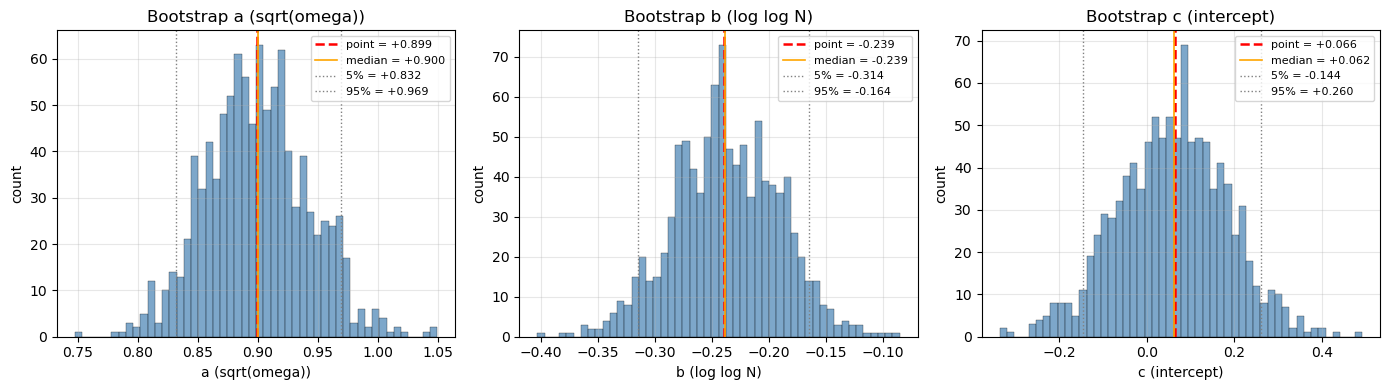

saved: fig8_bootstrap.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, (ax, lab) in enumerate(zip(axes, labels)):
    c = coefs[:, i]
    lo, med, hi = np.percentile(c, [5, 50, 95])
    ax.hist(c, bins=50, alpha=0.7, color='steelblue', edgecolor='k', linewidth=0.3)
    ax.axvline(point[i], color='red', ls='--', linewidth=1.8, label=f'point = {point[i]:+.3f}')
    ax.axvline(med, color='orange', ls='-', linewidth=1.2, label=f'median = {med:+.3f}')
    ax.axvline(lo, color='gray', ls=':', linewidth=1, label=f'5% = {lo:+.3f}')
    ax.axvline(hi, color='gray', ls=':', linewidth=1, label=f'95% = {hi:+.3f}')
    ax.set_xlabel(lab); ax.set_ylabel('count')
    ax.set_title(f'Bootstrap {lab}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_bootstrap.png', dpi=130, bbox_inches='tight')
plt.show()
print('saved: fig8_bootstrap.png')

## Paper section 4.3 — fill-in snippet

Once this notebook runs, paste the printed `90% CI` line into the paper:

```latex
\item $a \in [A_{lo}, A_{hi}]$, \quad $b \in [B_{lo}, B_{hi}]$, \quad $c \in [C_{lo}, C_{hi}]$.
```

and reference the saved figure `fig8_bootstrap.png` in the figure placeholder.